# Sinusoid: Bayesian FR converges to FR as $\alpha_D$ grows

FR energy $\mathcal{I}_t$ vs Bayesian FR energy $\widetilde{\mathcal{I}}_t$ along the curve at $N=20$, over $\alpha_D$ ($k=10$, $t=$ `T_SLICE`); no sampling. Writes `all_figures/supp_bayesian_convergence.pdf`.

In [1]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO = os.path.abspath("../..")
sys.path.insert(0, os.path.join(REPO, "src"))

from guidance import basic_fr, bayesian_fr
from plotting import wsstyle

wsstyle.large_style()

In [2]:
CKPT = os.path.join(REPO, "experiments", "sinusoid", "checkpoints", "score_normal_N20.pt")

# "manifold": slice along the curve parameter u; "horizontal": the line y=0
SLICE = "manifold"

T_SLICE = float(os.environ.get("T_SLICE", 0.05))   # late diffusion time
Q_TARGET = 0.9         # as in sinusoid.FR_SETTINGS
K_GRID = [10]
ALPHA_GRID = [0.1, 0.5, 1.0, 2.0]
B_BOOTSTRAP = 256
N_QUERY = 1600

ckpt = torch.load(CKPT, weights_only=False)
tc = ckpt["config"]
X_atoms = ckpt["X_target"].cpu()
BETA_MIN, BETA_MAX = tc["beta_min"], tc["beta_max"]
N_ATOMS = X_atoms.shape[0]


def alpha_bar(t):
    t = torch.as_tensor(t, dtype=torch.float32)
    return torch.exp(-(BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2))


def sigma2(t):
    return (1.0 - alpha_bar(t)).clamp(min=1e-6)


S2 = sigma2(T_SLICE)

U_LO, U_HI = -3.1, 2.9
u_grid = torch.linspace(U_LO, U_HI, N_QUERY)
if SLICE == "manifold":
    Z = torch.stack([u_grid, 0.6 * torch.sin(2 * u_grid)], dim=-1)
else:
    Z = torch.stack([u_grid, torch.zeros_like(u_grid)], dim=-1)
beta_t = S2.expand(Z.shape[0])

print(f"atoms N={N_ATOMS}  slice={SLICE}  t={T_SLICE}  sigma^2={S2.item():.4f}  q_target={Q_TARGET}")
print(f"alpha_D grid {ALPHA_GRID}   B={B_BOOTSTRAP}   k grid {K_GRID}")

atoms N=20  slice=manifold  t=0.05  sigma^2=0.0294  q_target=0.9
alpha_D grid [0.1, 0.5, 1.0, 2.0]   B=256   k grid [10]


## Energies

Both methods use the same neighbours and softmax temperature.

In [3]:
def knn(k):
    d2 = torch.cdist(Z, X_atoms) ** 2
    sq_d, idx = torch.topk(d2, k, largest=False, dim=1)
    return X_atoms[idx], sq_d, idx


def curves_for(k):
    neighbors, sq_d, idx = knn(k)
    beta_soft = basic_fr.beta_soft_for(sq_d, Q_TARGET)

    I_fr, q_fr, _ = basic_fr.fisher_rao_energy(Z, neighbors, beta_t, beta_soft=beta_soft)

    bayes = {}
    for a in ALPHA_GRID:
        I_b, _, _ = bayesian_fr.fisher_rao_energy_bb(
            Z, neighbors, beta_t, B=B_BOOTSTRAP, dirichlet_alpha=a, beta_soft=beta_soft,
            generator=torch.Generator().manual_seed(0))
        bayes[a] = I_b.detach().numpy()

    # cell walls: where the argmax atom (global index) changes
    owner = idx.gather(1, q_fr.argmax(1, keepdim=True)).squeeze(1).numpy()
    walls = u_grid.numpy()[:-1][owner[:-1] != owner[1:]]
    return {"fr": I_fr.detach().numpy(), "bayes": bayes, "walls": walls, "owner": owner}


results = {k: curves_for(k) for k in K_GRID}
for k, r in results.items():
    peak = max(r["fr"].max(), max(c.max() for c in r["bayes"].values()))
    print(f"k={k:>3}  cell walls on the slice: {len(r['walls']):>2}   peak I = {peak:.3g}")

k= 10  cell walls on the slice: 19   peak I = 376


## Render

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/all_figures/supp_bayesian_convergence.pdf']


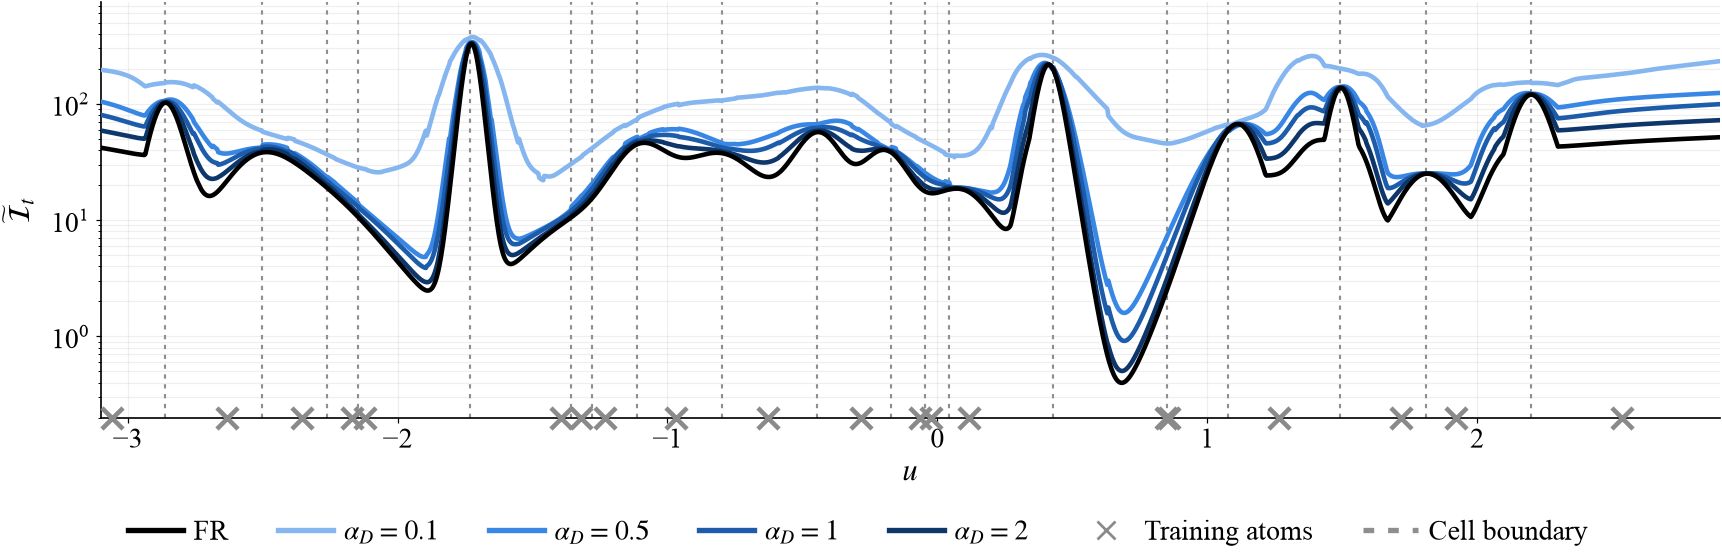

In [4]:
# alpha_D is ordered: one-hue sequential ramp, darkening toward the FR limit (black)
ALPHA_COLORS = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
FR_COLOR = "#000000"
WALL_COLOR = "#8E8E8E"
ATOM_COLOR = wsstyle.C["atoms"]

r = results[K_GRID[0]]
fig, ax = plt.subplots(figsize=(wsstyle.FULL_WIDTH, 5.4))
fig.subplots_adjust(left=0.07, right=0.99, top=0.97, bottom=0.27)

for w in r["walls"]:
    ax.axvline(w, color=WALL_COLOR, lw=1.4, ls=(0, (2, 2.6)), zorder=0)
for a, col in zip(ALPHA_GRID, ALPHA_COLORS):
    ax.plot(u_grid.numpy(), r["bayes"][a], color=col, lw=3.0, zorder=3)
ax.plot(u_grid.numpy(), r["fr"], color=FR_COLOR, lw=3.0, zorder=4)
# atoms on the u axis (axes coordinates in y, as the y axis is log)
ax.scatter(X_atoms[:, 0].numpy(), np.zeros(N_ATOMS), s=190, marker="x", color=ATOM_COLOR, linewidths=3.0,
           clip_on=False, zorder=6, transform=ax.get_xaxis_transform())

wsstyle.grid_on(ax)
ax.set_xlim(U_LO, U_HI)
ax.set_yscale("log")
ax.set_ylim(r["fr"].min() / 2, max(r["fr"].max(), max(c.max() for c in r["bayes"].values())) * 2)
ax.set_xlabel("$u$" if SLICE == "manifold" else "$x$")
ax.set_ylabel(r"$\widetilde{\mathcal{I}}_t$", labelpad=10)

entries = [("FR", "line", FR_COLOR)]
entries += [(rf"$\alpha_D = {a:g}$", "line", col) for a, col in zip(ALPHA_GRID, ALPHA_COLORS)]
entries += [("Training atoms", "cross", ATOM_COLOR), ("Cell boundary", "line", WALL_COLOR, (0, (2, 2.6)))]
wsstyle.figure_legend(fig, entries, ncol=len(entries), y=0.14, loc="upper center")

print(wsstyle.save(fig, "supp_bayesian_convergence"))
